In [1]:
# Cell 1: Plot chip centers with coastline (fix PROJ error)
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
import geopandas as gpd
import glob
import os

train_val = 'validation' # 'validation', 'training'
lgrip_dir = '/discover/nobackup/ejalilva/data/irrigation_FM'
chips_folder = f'/discover/nobackup/ejalilva/data/irrigation_FM/cdl_likelihood_mask/ir_likelihood_{train_val}'
output_dir = os.path.join(lgrip_dir,f'ir_{train_val}_chips')
os.makedirs(output_dir, exist_ok=True)

In [2]:
# Get all chips and transform bounds instead of points

chip_files = glob.glob(f"{chips_folder}/irr*.tif")

lons, lats = [], []
for i, chip_file in enumerate(chip_files):
    with rasterio.open(chip_file) as src:
        # Use transform_bounds instead of transform to avoid PROJ error
        bounds_4326 = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)
        center_lon = (bounds_4326[0] + bounds_4326[2]) / 2
        center_lat = (bounds_4326[1] + bounds_4326[3]) / 2
        lons.append(center_lon)
        lats.append(center_lat)
    
    if (i + 1) % 50 == 0 or (i + 1) == len(chip_files):
        print(f"Processed {i+1}/{len(chip_files)} chips")

Processed 50/771 chips
Processed 100/771 chips
Processed 150/771 chips
Processed 200/771 chips
Processed 250/771 chips
Processed 300/771 chips
Processed 350/771 chips
Processed 400/771 chips
Processed 450/771 chips
Processed 500/771 chips
Processed 550/771 chips
Processed 600/771 chips
Processed 650/771 chips
Processed 700/771 chips
Processed 750/771 chips
Processed 771/771 chips


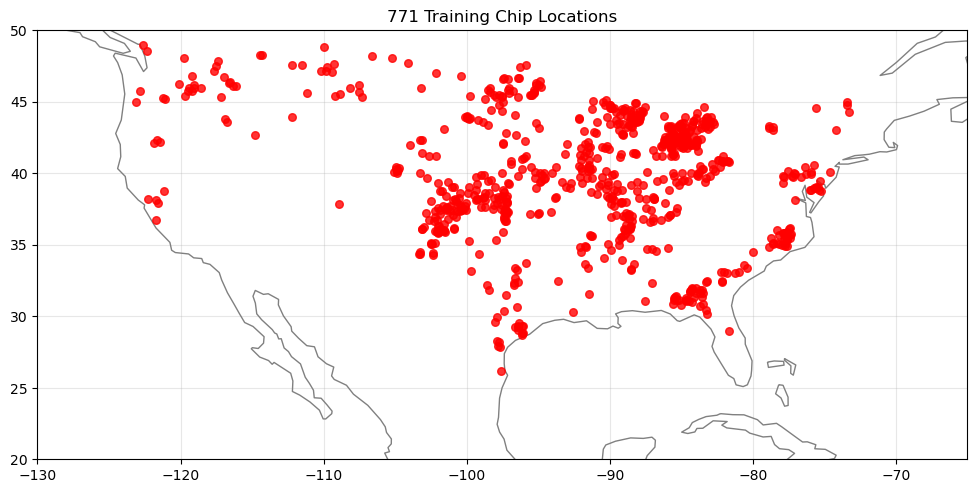

Plotted 771 chips


In [3]:
# Plot with coastlines
fig, ax = plt.subplots(figsize=(12, 8))

# Plot coastlines
coastline_dir = '/discover/nobackup/ejalilva/data/coastline'
coast_shp = os.path.join(coastline_dir, 'ne_110m_coastline.shp')
coastline = gpd.read_file(coast_shp)
coastline.plot(ax=ax, edgecolor='gray', linewidth=1)

# Plot chip centers
ax.scatter(lons, lats, c='red', s=30, alpha=0.8, zorder=5)

ax.set_xlim(-130, -65)
ax.set_ylim(20, 50)
ax.set_title(f'{len(chip_files)} Training Chip Locations')
ax.grid(True, alpha=0.3)
plt.show()

print(f"Plotted {len(chip_files)} chips")

# finding overlapping chips with each lgrip tile

In [47]:
lgrip_dir = '/discover/nobackup/ejalilva/data/irrigation_FM'
lgrip_files = glob.glob(f"{lgrip_dir}/LGRIP30_*.tif")
overlaps = {}

for lgrip_file in lgrip_files:
    lgrip_name = os.path.basename(lgrip_file)
    with rasterio.open(lgrip_file) as src:
        bounds = src.bounds
    
    intersecting_chips = []
    for i, (lon, lat) in enumerate(zip(lons, lats)):
        if bounds.left <= lon <= bounds.right and bounds.bottom <= lat <= bounds.top:
            intersecting_chips.append(os.path.basename(chip_files[i]))
    
    overlaps[lgrip_name] = intersecting_chips
    print(f"{lgrip_name}: {len(intersecting_chips)} intersecting chips")

LGRIP30_L3_2020_N20W80_002_202408210000.tif: 0 intersecting chips
LGRIP30_L3_2020_N20W110_002_202408210000.tif: 0 intersecting chips
LGRIP30_L3_2020_N30W130_002_202408210000.tif: 5 intersecting chips
LGRIP30_L3_2020_N30W100_002_202408210000.tif: 116 intersecting chips
LGRIP30_L3_2020_N40W100_002_202408210000.tif: 104 intersecting chips
LGRIP30_L3_2020_N40W90_002_202408210000.tif: 190 intersecting chips
LGRIP30_L3_2020_N20W100_002_202408210000.tif: 17 intersecting chips
LGRIP30_L3_2020_N40W120_002_202408210000.tif: 28 intersecting chips
LGRIP30_L3_2020_N40W130_002_202408210000.tif: 10 intersecting chips
LGRIP30_L3_2020_N30W90_002_202408210000.tif: 134 intersecting chips
LGRIP30_L3_2020_N40W70_002_202408210000.tif: 0 intersecting chips
LGRIP30_L3_2020_N40W80_002_202408210000.tif: 15 intersecting chips
LGRIP30_L3_2020_N20W90_002_202408210000.tif: 1 intersecting chips
LGRIP30_L3_2020_N30W110_002_202408210000.tif: 76 intersecting chips
LGRIP30_L3_2020_N30W120_002_202408210000.tif: 0 interse

In [3]:
import os
import rasterio
import numpy as np
from osgeo import gdal
from pathlib import Path
import pandas as pd

# Process all LGRIP tiles with >1 intersecting chip
recommended_tiles = [
    'LGRIP30_L3_2020_N40W90_002_202408210000.tif',   # 609 chips
    'LGRIP30_L3_2020_N30W90_002_202408210000.tif',   # 562 chips
    'LGRIP30_L3_2020_N30W100_002_202408210000.tif',  # 482 chips
    'LGRIP30_L3_2020_N40W100_002_202408210000.tif',  # 446 chips
    'LGRIP30_L3_2020_N30W110_002_202408210000.tif',  # 284 chips
    'LGRIP30_L3_2020_N30W80_002_202408210000.tif',   # 186 chips
    'LGRIP30_L3_2020_N40W110_002_202408210000.tif',  # 175 chips
    'LGRIP30_L3_2020_N40W120_002_202408210000.tif',  # 165 chips
    'LGRIP30_L3_2020_N40W80_002_202408210000.tif',   # 59 chips
    'LGRIP30_L3_2020_N20W100_002_202408210000.tif',  # 55 chips
    'LGRIP30_L3_2020_N40W130_002_202408210000.tif',  # 26 chips
    'LGRIP30_L3_2020_N30W130_002_202408210000.tif',  # 18 chips
    'LGRIP30_L3_2020_N30W120_002_202408210000.tif',  # 11 chips
    'LGRIP30_L3_2020_N20W90_002_202408210000.tif'    # 7 chips
]

region_mapping = {
    'LGRIP30_L3_2020_N40W90_002_202408210000.tif': 'corn_belt',
    'LGRIP30_L3_2020_N30W90_002_202408210000.tif': 'mississippi_delta',
    'LGRIP30_L3_2020_N30W100_002_202408210000.tif': 'texas_high_plains',
    'LGRIP30_L3_2020_N40W100_002_202408210000.tif': 'central_high_plains',
    'LGRIP30_L3_2020_N30W110_002_202408210000.tif': 'desert_southwest',
    'LGRIP30_L3_2020_N30W80_002_202408210000.tif': 'southeast_coastal',
    'LGRIP30_L3_2020_N40W110_002_202408210000.tif': 'intermountain_west',
    'LGRIP30_L3_2020_N40W120_002_202408210000.tif': 'pacific_northwest',
    'LGRIP30_L3_2020_N40W80_002_202408210000.tif': 'eastern_corn_belt',
    'LGRIP30_L3_2020_N20W100_002_202408210000.tif': 'rio_grande_valley',
    'LGRIP30_L3_2020_N40W130_002_202408210000.tif': 'coastal_pacific_nw',
    'LGRIP30_L3_2020_N30W130_002_202408210000.tif': 'socal_border',
    'LGRIP30_L3_2020_N30W120_002_202408210000.tif': 'southern_california',
    'LGRIP30_L3_2020_N20W90_002_202408210000.tif': 'gulf_coast'
}

In [4]:
"""
Bayesian Irrigation Classification Update
Combines CDL irrigation likelihood (prior) with LGRIP observations to produce posterior probabilities
"""

import os
import glob
import numpy as np
import rioxarray as rio
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import geopandas as gpd
import pandas as pd
from osgeo import gdal


# =======================
# BAYESIAN MODEL SETUP
# =======================

def cdl_class_to_prior(cdl_class):
    """
    Convert CDL irrigation likelihood class to prior probability
    
    CDL Classes:
    0 = No Data → 0.0
    1 = Highly Likely → 0.85
    2 = Likely → 0.65
    3 = Possibly → 0.40
    4 = Unlikely → 0.15
    5 = Non-Ag → 0.0
    6 = Water → 0.0
    """
    prior_map = {
        0: 0.00,  # No Data
        1: 0.85,  # Highly Likely
        2: 0.65,  # Likely
        3: 0.40,  # Possibly
        4: 0.15,  # Unlikely
        5: 0.00,  # Non-Ag
        6: 0.00   # Water
    }
    return np.vectorize(prior_map.get)(cdl_class) # np.vectorize apply prior_map.get method to each element of cdl_class which is a np array

In [5]:
def lgrip_likelihood_model(lgrip_class, irrigated=True):
    """
    Likelihood model: P(LGRIP observation | Irrigation status)
    
    LGRIP Classes:
    0 = Ocean/Water
    1 = Non-croplands
    2 = Irrigated croplands
    3 = Rainfed croplands
    
    Empirical likelihood from LGRIP V002 accuracy assessment (Table 1)
    N=11,104 validation samples, overall accuracy 91.2%
    LGRIP=Rainfed | Truth=Irrigated (651/7124) 0.909
    LGRIP=Irrigated | Truth=Irrigated (6473/7124) 0.091
    LGRIP=Irrigated | Truth=Rainfed (329/3980) 0.083
    LGRIP=Rainfed | Truth=Rainfed (3651/3980) 0.917
    """
    if irrigated:
        # P(LGRIP | Actually Irrigated) - from producer's accuracy
        likelihood_map = {
            0: 0.01,   # Water (not in confusion matrix, keep low)
            1: 0.01,   # Non-cropland (not in matrix, keep low)
            2: 0.909,  # LGRIP=Irrigated | Truth=Irrigated (6473/7124)
            3: 0.091   # LGRIP=Rainfed | Truth=Irrigated (651/7124)
        }
    else:
        # P(LGRIP | Actually NOT Irrigated) - from commission errors
        likelihood_map = {
            0: 0.05,   # Water
            1: 0.85,   # Non-cropland (assume mostly correct)
            2: 0.083,  # LGRIP=Irrigated | Truth=Rainfed (329/3980)
            3: 0.917   # LGRIP=Rainfed | Truth=Rainfed (3651/3980)
        }
    return np.vectorize(likelihood_map.get)(lgrip_class)

In [6]:
def bayesian_update(prior_prob, lgrip_class, alpha=1):
    """
    Bayesian update: P(Irrigated | LGRIP) ∝ P(LGRIP | Irrigated) × P(Irrigated)
    alpha=0.8 accounts for CDL-LGRIP correlation (both use satellite data)
    Args:
        prior_prob: Prior probability of irrigation [0-1]
        lgrip_class: LGRIP observation class [0-3]
        alpha: independance precentage
    Returns:
        posterior_prob: Updated probability of irrigation [0-1]
    """
    # Handle special cases
    mask_nodata = (lgrip_class == 0) | (prior_prob == 0)
    
    # Calculate likelihoods
    likelihood_irrigated = lgrip_likelihood_model(lgrip_class, irrigated=True)
    likelihood_not_irrigated = lgrip_likelihood_model(lgrip_class, irrigated=False)
    
    # Bayes' theorem
    # P(I|L) = P(L|I) × P(I) / [P(L|I) × P(I) + P(L|~I) × P(~I)]
    numerator = likelihood_irrigated * prior_prob
    denominator = (likelihood_irrigated * prior_prob + 
                   likelihood_not_irrigated * (1 - prior_prob))
    
    # Avoid division by zero
    posterior_full = np.divide(numerator, denominator, 
                               out=np.zeros_like(numerator), 
                               where=denominator != 0)
    posterior_prob = alpha * posterior_full + (1-alpha) * prior_prob
    
    # Set nodata/water to 0
    posterior_prob[mask_nodata] = 0
    
    return posterior_prob


def discretize_posterior(posterior_prob, cdl_class, thresholds=[0.2, 0.4, 0.6, 0.8]):
    """
    Convert continuous posterior probability to discrete classes
    
    Returns:
        0 = No Data / Water
        1 = Very Unlikely (<0.2)
        2 = Unlikely (0.2-0.4)
        3 = Possibly (0.4-0.6)
        4 = Likely (0.6-0.8)
        5 = Highly Likely (>0.8)
    """
    discrete = np.zeros_like(posterior_prob, dtype=np.uint8)
    water_mask = (cdl_class == 6)  # CDL sources
    nonag_mask = (cdl_class == 5)  # CDL sources
    cropland = ~(water_mask | nonag_mask) & (posterior_prob > 0)
    discrete[cropland & (posterior_prob <= thresholds[1])] = 2
    discrete[cropland & (posterior_prob > thresholds[1]) & (posterior_prob <= thresholds[2])] = 3
    discrete[cropland & (posterior_prob > thresholds[2]) & (posterior_prob <= thresholds[3])] = 4
    discrete[cropland & (posterior_prob > thresholds[3])] = 5
    discrete[water_mask] = 0
    discrete[nonag_mask] = 1
    return discrete

def posterior_to_lgrip_style(posterior_prob, cdl_class, lgrip_class, threshold=0.5):
    """
    4-class LGRIP format: 0=Water, 1=NonCrop, 2=Irrigated(>50%), 3=Rainfed(≤50%)
    """
    lgrip4 = np.zeros_like(posterior_prob, dtype=np.uint8)
    water_mask = (cdl_class == 6)  # CDL sources
    nonag_mask = (cdl_class == 5)  # CDL sources
    lgrip4[water_mask] = 0
    lgrip4[nonag_mask] = 1
    cropland = ~(water_mask | nonag_mask) & (posterior_prob > 0)
    lgrip4[cropland & (posterior_prob > threshold)] = 2
    lgrip4[cropland & (posterior_prob <= threshold)] = 3
    return lgrip4

In [7]:
# =======================
# VISUALIZATION FUNCTIONS
# =======================

def create_colormaps():
    """Create all colormaps for visualization"""
    
    # CDL Irrigation Likelihood (7 classes)
    cdl_colors = {
        0: '#2c3e50',  # No Data - dark gray
        1: '#e74c3c',  # Highly Likely - red
        2: '#f39c12',  # Likely - orange
        3: '#f1c40f',  # Possibly - yellow
        4: '#2ecc71',  # Unlikely - green
        5: '#95a5a6',  # Non-Ag - light gray
        6: '#4d70a3',  # Water - blue
    }
    cdl_labels = ["No Data", "Highly Likely", "Likely", "Possibly", 
                  "Unlikely", "Non-Ag", "Water"]
    cdl_cmap = ListedColormap([cdl_colors[i] for i in range(7)])
    
    # LGRIP (4 classes)
    lgrip_colors = ['#4d70a3', '#8c564b', '#2ca02c', '#98df8a']
    lgrip_labels = ['Ocean/Water', 'Non-cropland', 'Irrigated', 'Rainfed']
    lgrip_cmap = ListedColormap(lgrip_colors)
    
    # Posterior Discrete (6 classes)
    posterior_colors = {
        0: '#4d70a3',  # Water - blue (match CDL)
        1: '#95a5a6',  # Non-Ag - gray (match CDL)
        2: '#f4d03f',  # Very Unlikely - yellow
        3: '#f7dc6f',  # Possibly - light yellow
        4: '#82e0aa',  # Likely - light green
        5: '#27ae60',  # Highly Likely - dark green (irrigated)
    }
    posterior_labels = ["Water", "Non-Ag", "Very Unlikely (<20%)", 
                        "Possibly (40-60%)", "Likely (60-80%)", "Highly Likely (>80%)"]
    posterior_cmap = ListedColormap([posterior_colors[i] for i in range(6)])
    
    # Continuous posterior (for heatmap)
    continuous_cmap = plt.cm.RdYlGn_r  # Red = high irrigation prob, Green = low
    
    return {
        'cdl': (cdl_cmap, cdl_labels),
        'lgrip': (lgrip_cmap, lgrip_labels),
        'posterior': (posterior_cmap, posterior_labels),
        'continuous': continuous_cmap
    }


def plot_bayesian_update(cdl_data, lgrip_data, prior_prob, posterior_prob, 
                         posterior_discrete, posterior_lgrip_style, chip_idx, save_path=None):
    """
    Create 5-panel visualization showing Bayesian update process
    """
    cmaps = create_colormaps()
    
    fig, axes = plt.subplots(2, 3, figsize=(24, 14))
    fig.suptitle(f'Bayesian Irrigation Update - Chip {chip_idx}', 
                 fontsize=18, fontweight='bold')
    
    # 1. CDL Irrigation Likelihood (Prior Classes)
    im0 = axes[0, 0].imshow(cdl_data, cmap=cmaps['cdl'][0], vmin=-0.5, vmax=6.5)
    cbar0 = plt.colorbar(im0, ax=axes[0, 0], ticks=np.arange(7))
    cbar0.ax.set_yticklabels(cmaps['cdl'][1])
    axes[0, 0].set_title('1. Prior: CDL Irrigation Likelihood', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    # 2. Prior Probability (Continuous)
    im1 = axes[0, 1].imshow(prior_prob, cmap=cmaps['continuous'], vmin=0, vmax=1)
    cbar1 = plt.colorbar(im1, ax=axes[0, 1])
    cbar1.set_label('Prior P(Irrigated)', fontsize=12)
    axes[0, 1].set_title('2. Prior Probability (Continuous)', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    # 3. LGRIP Observation
    im2 = axes[0, 2].imshow(lgrip_data, cmap=cmaps['lgrip'][0], vmin=0, vmax=3)
    cbar2 = plt.colorbar(im2, ax=axes[0, 2], ticks=[0.375, 1.125, 1.875, 2.625])
    cbar2.ax.set_yticklabels(cmaps['lgrip'][1])
    axes[0, 2].set_title('3. Observation: LGRIP Classification', fontsize=14, fontweight='bold')
    axes[0, 2].axis('off')
    
    # 4. Posterior Probability (Continuous)
    im3 = axes[1, 0].imshow(posterior_prob, cmap=cmaps['continuous'], vmin=0, vmax=1)
    cbar3 = plt.colorbar(im3, ax=axes[1, 0])
    cbar3.set_label('Posterior P(Irrigated | LGRIP)', fontsize=12)
    axes[1, 0].set_title('4. Posterior Probability (Continuous)', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    
    # 5. Posterior Discrete Classes
    im4 = axes[1, 1].imshow(posterior_discrete, cmap=cmaps['posterior'][0], vmin=-0.5, vmax=5.5)
    cbar4 = plt.colorbar(im4, ax=axes[1, 1], ticks=np.arange(6))
    cbar4.ax.set_yticklabels(cmaps['posterior'][1])
    axes[1, 1].set_title('5. Posterior: Discrete Classes', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    
    # 6. Change from Prior to Posterior
    im5 = axes[1, 2].imshow(posterior_lgrip_style, cmap=cmaps['lgrip'][0], vmin=0, vmax=3)
    cbar5 = plt.colorbar(im5, ax=axes[1, 2], ticks=[0.375, 1.125, 1.875, 2.625])
    cbar5.ax.set_yticklabels(cmaps['lgrip'][1])
    cbar5.set_label('Posterior LGRIP style', fontsize=12)
    axes[1, 2].set_title('6. Posterior: Discrete LGRIP style Classes', fontsize=14, fontweight='bold')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved visualization to {save_path}")
    
    plt.show()
    # change = posterior_prob - prior_prob    # Print statistics
    # print(f"\n=== Statistics for Chip {chip_idx} ===")
    # print(f"Prior mean probability: {prior_prob[prior_prob > 0].mean():.3f}")
    # print(f"Posterior mean probability: {posterior_prob[posterior_prob > 0].mean():.3f}")
    # print(f"Mean change: {change[prior_prob > 0].mean():.3f}")
    # print(f"Pixels with increased belief: {(change > 0.1).sum()}")
    # print(f"Pixels with decreased belief: {(change < -0.1).sum()}")

In [8]:
# Main loop here
region = 1; # determine wether to save the file by the region or all in the same folder
for tile_name in recommended_tiles:
    # Create region-specific folder
    region_name = region_mapping[tile_name]
    if region == 1:
        region_output_dir = os.path.join(output_dir, region_name)
    else:
        region_output_dir = output_dir

    os.makedirs(region_output_dir, exist_ok=True)
    
    lgrip_file = os.path.join(lgrip_dir, tile_name)
    intersecting_chips = overlaps[tile_name]
    
    print(f"\n=== Processing {tile_name} ({region_name}) ===")
    print(f"Processing {len(intersecting_chips)} chips")
    
    # Track processed chips for this region
    processed_chips = []
    
    for i, chip_name in enumerate(intersecting_chips):
        chip_path = os.path.join(chips_folder, chip_name)
        
        try:
            # Load CDL chip
            with rasterio.open(chip_path) as cdl_src:
                cdl_data = cdl_src.read(1)
                profile = cdl_src.profile
                
                # Get CDL properties for alignment
                cdl_ds = gdal.Open(chip_path)
                cdl_proj = cdl_ds.GetProjection()
                cdl_gt = cdl_ds.GetGeoTransform()
                x_pixels, y_pixels = cdl_ds.RasterXSize, cdl_ds.RasterYSize
                
                # Calculate bounds
                minx, maxy = cdl_gt[0], cdl_gt[3]
                pixel_size_x, pixel_size_y = abs(cdl_gt[1]), abs(cdl_gt[5])
                maxx = minx + (x_pixels * pixel_size_x)
                miny = maxy - (y_pixels * pixel_size_y)
                cdl_ds = None
                
                # Align LGRIP to CDL
                temp_output = f"/tmp/temp_lgrip_{i}.tif"
                warp_options = gdal.WarpOptions(
                    outputBounds=[minx, miny, maxx, maxy],
                    width=x_pixels, height=y_pixels,
                    dstSRS=cdl_proj,
                    resampleAlg=gdal.GRA_NearestNeighbour,
                    dstNodata=0
                )
                gdal.Warp(temp_output, lgrip_file, options=warp_options)
                
                # Load aligned LGRIP
                with rasterio.open(temp_output) as lgrip_src:
                    lgrip_data = lgrip_src.read(1)
                
                prior_prob = cdl_class_to_prior(cdl_data)
                
                # Bayesian update
                posterior_prob = bayesian_update(prior_prob, lgrip_data)
                posterior_discrete = discretize_posterior(posterior_prob, cdl_data)
                result = posterior_to_lgrip_style(posterior_prob, cdl_data, lgrip_data, threshold=0.5)
                
                # Save result in region folder
                chip_num = chip_name.split('.')[0].split('d')[1]
                chip_save_name = f'chip{chip_num}.mask.tif'
                output_path = os.path.join(region_output_dir, chip_save_name)
                with rasterio.open(output_path, 'w', **profile) as dst:
                    dst.write(result.astype(profile['dtype']), 1)
                
                # Clean up
                os.remove(temp_output)
                
                # Track processed chip with both paths
                processed_chips.append({
                    'chip_name': chip_name,
                    'chip_path': chip_path,
                    'lgrip_path': lgrip_file,
                    'lgrip_name': tile_name,
                    'output_path': output_path
                })
                
                if (i + 1) % 10 == 0:
                    print(f"  Processed {i+1}/{len(intersecting_chips)} chips")
                    
        except Exception as e:
            print(f"  Error processing {chip_name}: {e}")
            continue
    
    # Write chip paths to files
    # Simple text file with both paths
    txt_file = os.path.join(region_output_dir, 'chip_paths.txt')
    with open(txt_file, 'w') as f:
        f.write("chip_path,lgrip_path\n")
        for chip_info in processed_chips:
            f.write(f"{chip_info['chip_path']},{chip_info['lgrip_path']}\n")
    
    # CSV file with more details
    csv_file = os.path.join(region_output_dir, 'chip_info.csv')
    df = pd.DataFrame(processed_chips)
    df.to_csv(csv_file, index=False)
    
    print(f"Completed {tile_name} -> {region_output_dir}")
    print(f"  Processed {len(processed_chips)} chips successfully")
    print(f"  Saved paths to: {txt_file} and {csv_file}")

NameError: name 'overlaps' is not defined

## Bayesian Irrigation Classification

**Combining CDL crop knowledge with LGRIP satellite observations**

### Logic:
```
P(Irrigated | LGRIP) = [P(LGRIP | Irrigated) × P(Irrigated)] / Evidence

Posterior = α × BayesUpdate + (1-α) × Prior
```

**Inputs:**
1. **CDL Prior** (Panel 1): Crop-based irrigation likelihood (0.85 for rice, 0.15 for soybeans, etc.)
2. **LGRIP Observation** (Panel 3): Satellite-detected irrigation (Irrigated/Rainfed)

**Likelihood from LGRIP confusion matrix (N=11,104):**
- P(LGRIP=Irrigated | Truth=Irrigated) = 90.9%
- P(LGRIP=Rainfed | Truth=Rainfed) = 91.7%

**Independence factor α=0.8:** Accounts for CDL↔LGRIP correlation (both use satellite data)

**Non-ag/Water:** Preserved from CDL (class 5,6) OR LGRIP (class 0,1)

**Output:**
- **Panel 2,4:** Continuous probabilities (0-1)
- **Panel 5:** Discrete classes (Yellow=rainfed → Green=irrigated)
- **Panel 6:** Change map (belief increase/decrease)

### 6-Panel Visualization:

In [11]:
# Create region-specific folder
tile_name = recommended_tiles[0]
region_name = region_mapping[tile_name]
# region_output_dir = os.path.join(output_dir, region_name)
# os.makedirs(region_output_dir, exist_ok=True)

lgrip_file = os.path.join(lgrip_dir, tile_name)
intersecting_chips = overlaps[tile_name]

print(f"\n=== Processing {tile_name} ({region_name}) ===")
print(f"Processing {len(intersecting_chips)} chips")


=== Processing LGRIP30_L3_2020_N40W90_002_202408210000.tif (corn_belt) ===
Processing 609 chips


In [20]:
i = 50
chip_name = intersecting_chips[i]

chip_path = os.path.join(chips_folder, chip_name)
    
# Load CDL chip
cdl_src = rasterio.open(chip_path)
cdl_data = cdl_src.read(1)
profile = cdl_src.profile

# Get CDL properties for alignment
cdl_ds = gdal.Open(chip_path)
cdl_proj = cdl_ds.GetProjection()
cdl_gt = cdl_ds.GetGeoTransform()
x_pixels, y_pixels = cdl_ds.RasterXSize, cdl_ds.RasterYSize

# Calculate bounds
minx, maxy = cdl_gt[0], cdl_gt[3]
pixel_size_x, pixel_size_y = abs(cdl_gt[1]), abs(cdl_gt[5])
maxx = minx + (x_pixels * pixel_size_x)
miny = maxy - (y_pixels * pixel_size_y)
cdl_ds = None

# Align LGRIP to CDL
temp_output = f"/tmp/temp_lgrip_{i}.tif"
warp_options = gdal.WarpOptions(
    outputBounds=[minx, miny, maxx, maxy],
    width=x_pixels, height=y_pixels,
    dstSRS=cdl_proj,
    resampleAlg=gdal.GRA_NearestNeighbour,
    dstNodata=0
)
gdal.Warp(temp_output, lgrip_file, options=warp_options)

# Load aligned LGRIP
with rasterio.open(temp_output) as lgrip_src:
    lgrip_data = lgrip_src.read(1)
lgrip_data
cdl_data

array([[3, 3, 3, ..., 3, 3, 3],
       [2, 2, 2, ..., 3, 3, 3],
       [2, 2, 2, ..., 3, 3, 3],
       ...,
       [3, 3, 3, ..., 5, 5, 5],
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3]], dtype=uint8)

In [23]:
prior_prob = cdl_class_to_prior(cdl_data)

# Bayesian update
posterior_prob = bayesian_update(prior_prob, lgrip_data)
posterior_discrete = discretize_posterior(posterior_prob, cdl_data)
posterior_lgrip_style = posterior_to_lgrip_style(posterior_prob, cdl_data, lgrip_data, threshold=0.5)

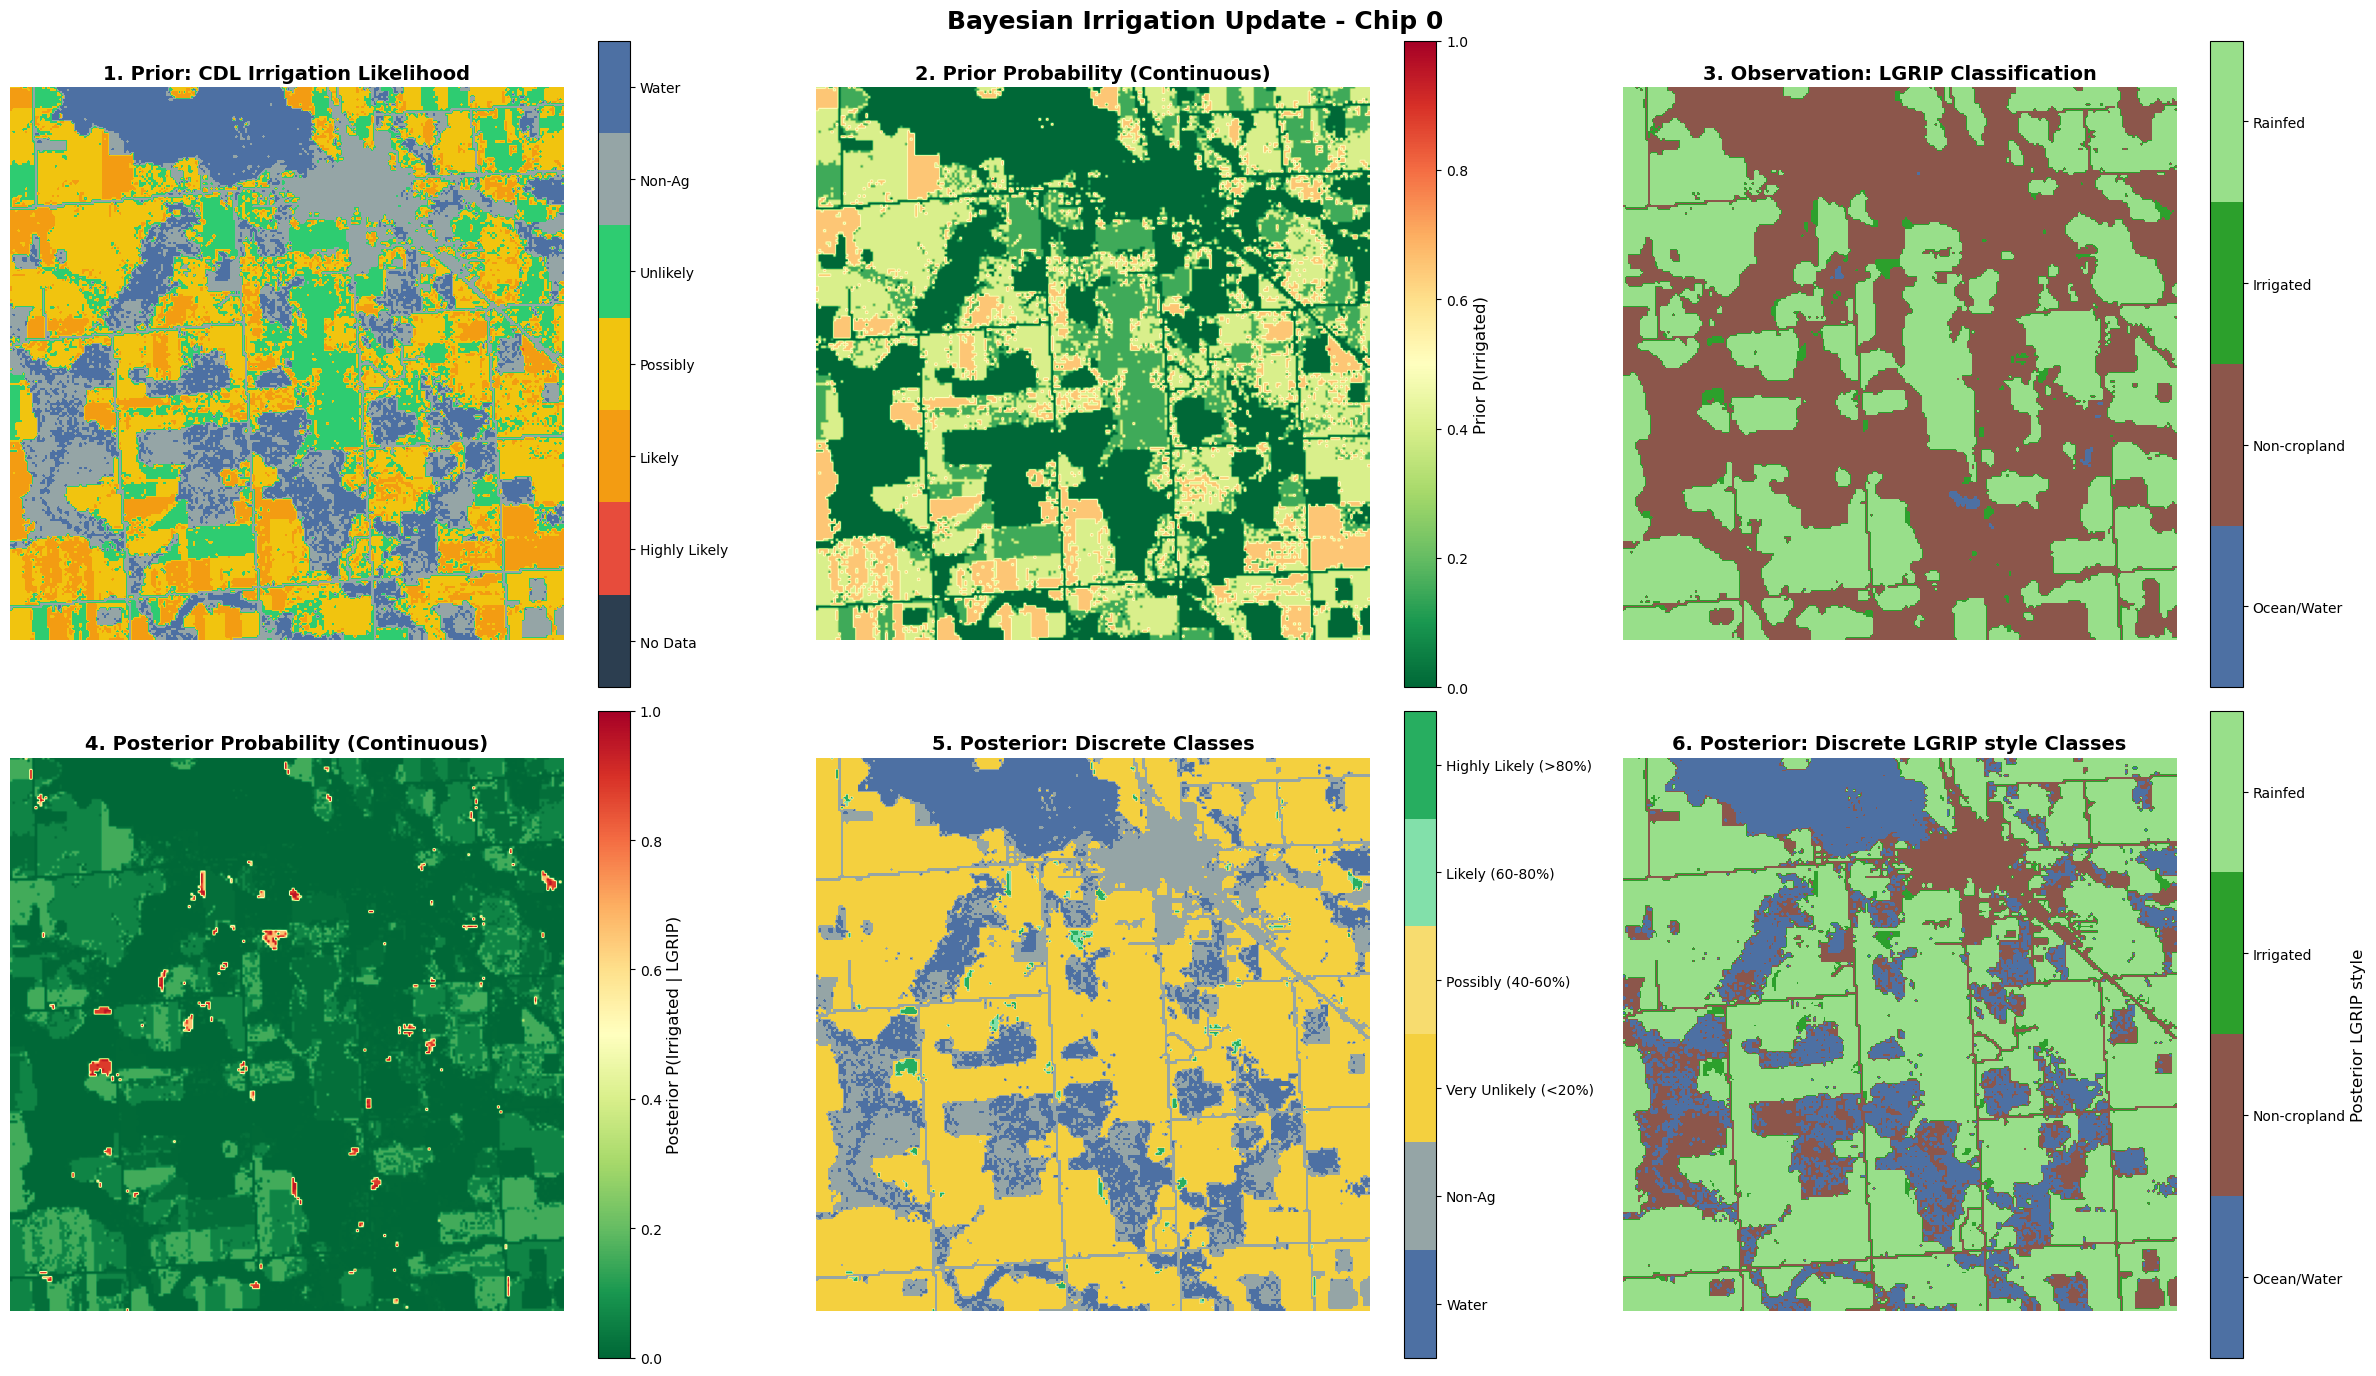

In [24]:
plot_bayesian_update(cdl_data, lgrip_data, prior_prob, posterior_prob, 
                         posterior_discrete,posterior_lgrip_style, 0, save_path=None)
